This notebook shows mismatch between lensed waveforms generated with normal lensing effects (i.e., time delay and effective distance change) and ones generated with additional second order corrections (angular changes and Doppler shift).

In [ ]:
import os
import sys
from pathlib import Path
import jax.numpy as np
import matplotlib.pyplot as plt

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MRSUN_SI, MTSUN_SI, uGpc
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.new_signal import BasicGWSignal, AGNLensedGWSignal
import gwfast.network as network
import gwfast.lensing_utils as lutils
from gwfast.lensing_utils_alt import get_agn_lensed_parameters, PML_time_delay_magnification, dLGridGlob, zGridGlob, einstein_angle

# Definitions

Note that currently the "normal" definition of mismatch is used, with values ranging from 0 to 2.

In [ ]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

# def mismatch(frequencies, h1, h2, psd):
#     return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

def mismatch(frequencies, h1, h2, psd):
    return 1 - inner_product(frequencies, h1, h2, psd) / np.sqrt(inner_product(frequencies, h1, h1, psd) * inner_product(frequencies, h2, h2, psd))

# Normal lensing (first order effects) definition
def normal_lens(FD_strain, events, freqs, separate=False):
    mag_1, mag_2 = lutils.get_mag_factors(events)
    time_delay = lutils.get_lensing_time_delay(events)
    time_delay_phase_shift = np.exp(2j * np.pi * freqs * time_delay)

    image_1 = np.sqrt(np.abs(mag_1)) * FD_strain
    image_2 = np.sqrt(np.abs(mag_2)) * FD_strain * time_delay_phase_shift
    if separate:
        return image_1, image_2
    else:
        return image_1 + image_2


# Normal lensing (first order effects) definition
# Yes, this needs to be simplified...
def normal_lens(FD_strain, events, freqs, separate=False):
    r_orbit = events['R_orbit']
    lens_mass = events['M_lz']
    luminosity_distance = events["dL"]
    y_src = events["src_pos"]
    d_LS = r_orbit * np.sqrt(1 - y_src**2)  # R_Sch
    _y_src = y_src * r_orbit  # R_Sch

    # Schwarschild radius
    # A small, but necessary assumption, that the lens is at dL
    z = np.interp(luminosity_distance, dLGridGlob, zGridGlob)
    lens_mass_src = lens_mass / (1 + z)
    R_Sch = 2 * lens_mass_src * MRSUN_SI  # m
    delta = R_Sch / uGpc

    beta = _y_src / luminosity_distance * delta  # Radian
    ang_D_S = luminosity_distance

    ang_D_L = ang_D_S / (1 + d_LS * delta)  # Gpc
    theta_E = einstein_angle(lens_mass_src, ang_D_L, ang_D_S)  # Radian
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
    time_delay *= lens_mass_src * MTSUN_SI  
    time_delay_phase_shift = np.exp(2j * np.pi * freqs * time_delay)

    image_1 = mag_1 * FD_strain
    image_2 = mag_2 * FD_strain * time_delay_phase_shift
    if separate:
        return image_1, image_2
    else:
        return image_1 + image_2

def PML_simple_lens_parameters(parameters):
    output_params = parameters.copy()
    r_orbit = output_params.pop('R_orbit')
    lens_mass = output_params.pop('M_lz')
    luminosity_distance = output_params.pop("dL")
    y_src = output_params.pop("src_pos")
    d_LS = r_orbit * np.sqrt(1 - y_src**2)  # R_Sch
    _y_src = y_src * r_orbit  # R_Sch

    # Schwarschild radius
    # A small, but necessary assumption, that the lens is at dL
    z = np.interp(luminosity_distance, dLGridGlob, zGridGlob)
    lens_mass_src = lens_mass / (1 + z)
    R_Sch = 2 * lens_mass_src * MRSUN_SI  # m
    delta = R_Sch / uGpc

    beta = _y_src / luminosity_distance * delta  # Radian
    ang_D_S = luminosity_distance
    ang_D_L = ang_D_S / (1 + d_LS * delta)  # Gpc
    theta_E = einstein_angle(lens_mass_src, ang_D_L, ang_D_S)  # Radian
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)

    output_params['delta_time'] = time_delay * lens_mass_src * MTSUN_SI  # s
    output_params['dL_1'] = luminosity_distance * mag_1
    output_params['dL_2'] = luminosity_distance * mag_2
    output_params['delta_iota'] = np.zeros_like(mag_1)  # No change in iota
    output_params['delta_phase'] = np.zeros_like(mag_1)  # No change in phi
    output_params['relative_mass'] = np.ones_like(mag_1)  # No change in phi
    return output_params


# Detector setup

In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

H1_BBH = BasicGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_BBH = BasicGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_BBH = BasicGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


# 1D

[-1.38645558e+01 -1.40443499e+01 -1.42269305e+01 -1.44123515e+01
 -1.46006681e+01 -1.47919370e+01 -1.49862157e+01 -1.51835636e+01
 -1.53840408e+01 -1.55877094e+01 -1.57946324e+01 -1.60048746e+01
 -1.62185021e+01 -1.64355825e+01 -1.66561850e+01 -1.68803804e+01
 -1.71082411e+01 -1.73398411e+01 -1.75752562e+01 -1.78145638e+01
 -1.80578431e+01 -1.83051753e+01 -1.85566432e+01 -1.88123316e+01
 -1.90723273e+01 -1.93367190e+01 -1.96055975e+01 -1.98790557e+01
 -2.01571884e+01 -2.04400929e+01 -2.07278684e+01 -2.10206167e+01
 -2.13184418e+01 -2.16214499e+01 -2.19297498e+01 -2.22434529e+01
 -2.25626729e+01 -2.28875263e+01 -2.32181322e+01 -2.35546123e+01
 -2.38970912e+01 -2.42456965e+01 -2.46005584e+01 -2.49618103e+01
 -2.53295885e+01 -2.57040325e+01 -2.60852851e+01 -2.64734921e+01
 -2.68688028e+01 -2.72713699e+01 -2.76813495e+01 -2.80989013e+01
 -2.85241887e+01 -2.89573787e+01 -2.93986421e+01 -2.98481538e+01
 -3.03060924e+01 -3.07726408e+01 -3.12479860e+01 -3.17323190e+01
 -3.22258356e+01 -3.27287

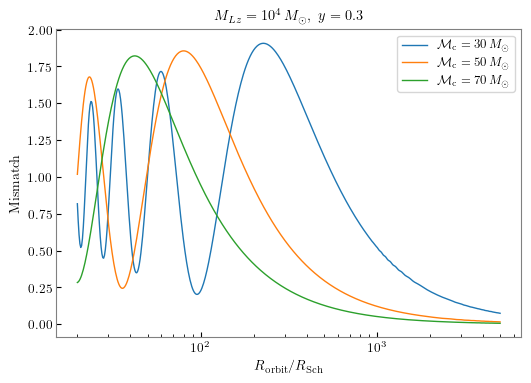

In [18]:
# Define a benchmark event
n = 500
shape = (n,)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.1)
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Waveform metadata
sampling_frequency = 1024.  # Hz
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2
N_freq_bins = 1000

# Make frequency grid
minimum_frequency_array = np.full(shape, minimum_frequency)
maximum_frequency_array = np.full(shape, maximum_frequency)
freq_grid = np.geomspace(minimum_frequency_array, maximum_frequency_array, N_freq_bins)

# Interpolate PSD
freq_array = np.geomspace(minimum_frequency, maximum_frequency, N_freq_bins)
psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = np.reshape(np.repeat(psd_interp, n), (-1, n))

# Sample values
# TODO: Check why the full lensing transformations don't work for R_orbit >~ 900
R_orbit_array = np.geomspace(20, 5000, n)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# M_lz fixed at 1e4*M_sun, src_pos fixed at 0.3
for Mc in [30, 50, 70]:
    # Prepare injections
    events_copy = events.copy()
    events_copy['R_orbit'] = R_orbit_array
    events_copy['Mc'] = np.full(n, Mc)

    # Generate strains from L1
    FD_strain_lensed = L1_AGN.GWstrain(freq_grid, events_copy)
    FD_strain_unlensed = L1_BBH.GWstrain(freq_grid, events_copy)

    # Combine unlensed waveforms to make normal lensed waveforms
    FD_strain_normal_lensed = normal_lens(FD_strain_unlensed, events_copy, freq_grid)

    # Compute mismatch
    _mismatch = mismatch(freq_grid, FD_strain_lensed, FD_strain_normal_lensed, psd_interp_grid)

    ax.plot(R_orbit_array, _mismatch, label=fr'${{\cal M}}_{{\rm c}}={Mc:.0f}\,M_\odot$')

ax.set_xscale('log')
ax.set_xlabel(r'$R_{\rm orbit}/R_{\rm Sch}$')
ax.set_ylabel('Mismatch')
ax.set_title(r'$M_{Lz} = 10^4\,M_{\odot},\ y = 0.3$')
ax.legend()

## Check waveforms

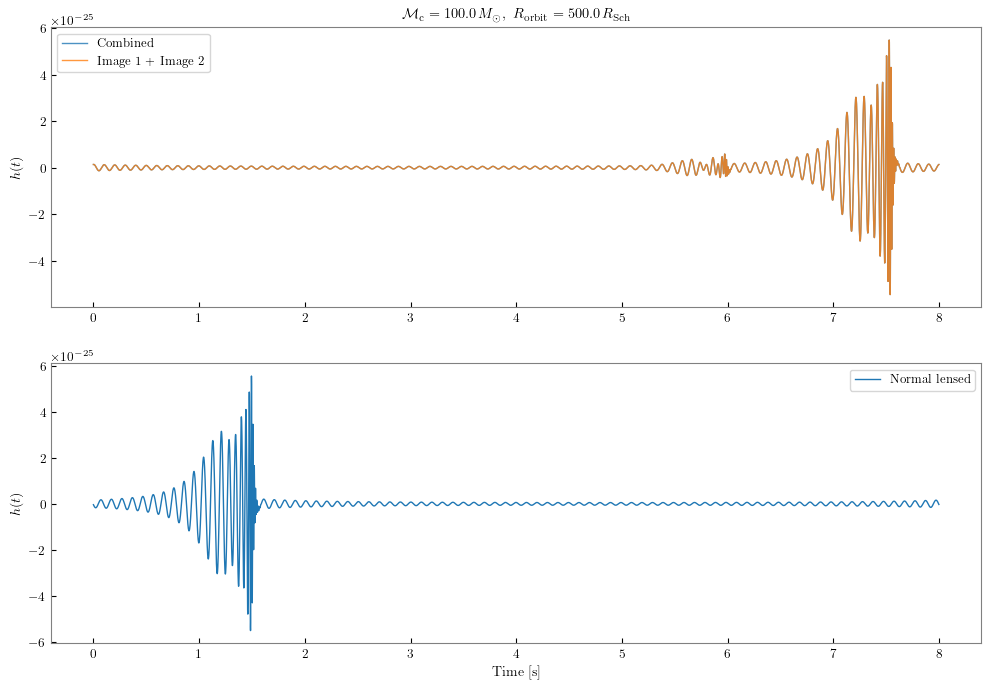

In [16]:
# Waveform metadata
sampling_frequency = 1024.  # Hz
duration = 8.  # 
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

FD_strain_lensed_plot = np.zeros_like(freq_array, dtype='complex128')
FD_strain_lensed_image_1_plot = np.zeros_like(freq_array, dtype='complex128')
FD_strain_lensed_image_2_plot = np.zeros_like(freq_array, dtype='complex128')
FD_strain_unlensed_plot = np.zeros_like(freq_array, dtype='complex128')

freq_mask = (freq_array > minimum_frequency) * (freq_array < maximum_frequency)
masked_freq_arr = freq_array[freq_mask]

# Select event
ev_index = -1
events_plot = {key: val[-1] for key, val in events_copy.items()}
events_plot['Mc'] = np.array(100)
events_plot['R_orbit'] = np.array(500)
events_plot['src_pos'] = np.array(-0.2)
events_plot['M_lz'] = np.array(1e5)

# Compute lensed strains with second order corrections
FD_strain_lensed_plot = FD_strain_lensed_plot.at[freq_mask].set(L1_AGN.GWstrain(masked_freq_arr, events_plot))
FD_image_1, FD_image_2 = L1_AGN.GWstrain(masked_freq_arr, events_plot, return_single_comp='images')
FD_strain_lensed_image_1_plot = FD_strain_lensed_image_1_plot.at[freq_mask].set(FD_image_1)
FD_strain_lensed_image_2_plot = FD_strain_lensed_image_2_plot.at[freq_mask].set(FD_image_2)
TD_strain_lensed_plot = np.fft.irfft(FD_strain_lensed_plot)
TD_strain_lensed_image_1_plot = np.fft.irfft(FD_strain_lensed_image_1_plot)
TD_strain_lensed_image_2_plot = np.fft.irfft(FD_strain_lensed_image_2_plot)

# Produce normal lensed waveforms
FD_strain_unlensed_plot = FD_strain_unlensed_plot.at[freq_mask].set(L1_BBH.GWstrain(masked_freq_arr, events_plot))
FD_strain_normal_lensed_plot = normal_lens(FD_strain_unlensed_plot, events_plot, freq_array)
TD_strain_normal_lensed_plot = np.fft.irfft(FD_strain_normal_lensed_plot)

# Wrap ringdown to the end
# TODO: Need to check how does GWstrain define the peak time
post_merger_time = -2
n_index = int(post_merger_time * sampling_frequency)
TD_strain_lensed_plot = np.roll(TD_strain_lensed_plot, n_index)
TD_strain_lensed_image_1_plot = np.roll(TD_strain_lensed_image_1_plot, n_index)
TD_strain_lensed_image_2_plot = np.roll(TD_strain_lensed_image_2_plot, n_index)
TD_strain_normal_lensed_plot = np.roll(TD_strain_normal_lensed_plot, n_index)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.plot(time_array, TD_strain_lensed_plot, alpha=0.8, label='Combined')
# ax.plot(time_array, TD_strain_lensed_image_1_plot, alpha=0.6, label='Image 1')
# ax.plot(time_array, TD_strain_lensed_image_2_plot, alpha=0.6, label='Image 2')
ax.plot(time_array, TD_strain_lensed_image_1_plot + TD_strain_lensed_image_2_plot, alpha=0.8, label='Image 1 + Image 2')
ax.set_ylabel(r'$h(t)$')
# ax.set_xlim(3, 8)
ax.legend()
ax.set_title(fr"$\mathcal{{M}}_{{\rm c}} = {float(events_plot['Mc']):.1f}\,M_\odot,\ R_{{\rm orbit}} = {float(events_plot['R_orbit']):.1f}\,R_{{\rm Sch}}$")

ax = axes[1]
ax.plot(time_array, TD_strain_normal_lensed_plot, label='Normal lensed')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$h(t)$')
# ax.set_xlim(3, 8)
ax.legend()

In [6]:
events_plot, L1_AGN.convert_to_flexible_model_parameters( events_plot)

({'Mc': Array(100., dtype=float64),
  'eta': Array(0.24, dtype=float64),
  'dL': Array(0.8, dtype=float64),
  'theta': Array(1.87, dtype=float64),
  'phi': Array(2.66, dtype=float64),
  'iota': Array(1.55508836, dtype=float64),
  'psi': Array(4., dtype=float64),
  'tcoal': Array(0., dtype=float64),
  'phase': Array(2., dtype=float64),
  'chi1z': Array(0.3, dtype=float64),
  'chi2z': Array(0.5, dtype=float64),
  'R_orbit': Array(500., dtype=float64),
  'M_lz': Array(100000., dtype=float64),
  'src_pos': Array(-0.2, dtype=float64)},
 {'chi2z': Array(0.5, dtype=float64),
  'phi': Array(2.66, dtype=float64),
  'eta': Array(0.24, dtype=float64),
  'M_lz': Array(100000., dtype=float64),
  'psi': Array(4., dtype=float64),
  'iota': Array(1.55022103, dtype=float64),
  'chi1z': Array(0.3, dtype=float64),
  'dL': Array(9.82632805, dtype=float64),
  'tcoal': Array(0., dtype=float64),
  'phase': Array(2.06306576, dtype=float64),
  'theta': Array(1.87, dtype=float64),
  'R_orbit': Array(500., dtype

In the upper plot, the blue waveform (blocked out) is constructed as ifft(FD image 1 + FD image 2), and the orange waveform is constructed as ifft(FD image 1) + ifft(FD image 1). The two waveforms coincide, which is good. The `hp + hc` convention is used.

# 2D

Text(0, 0.5, '$y$')

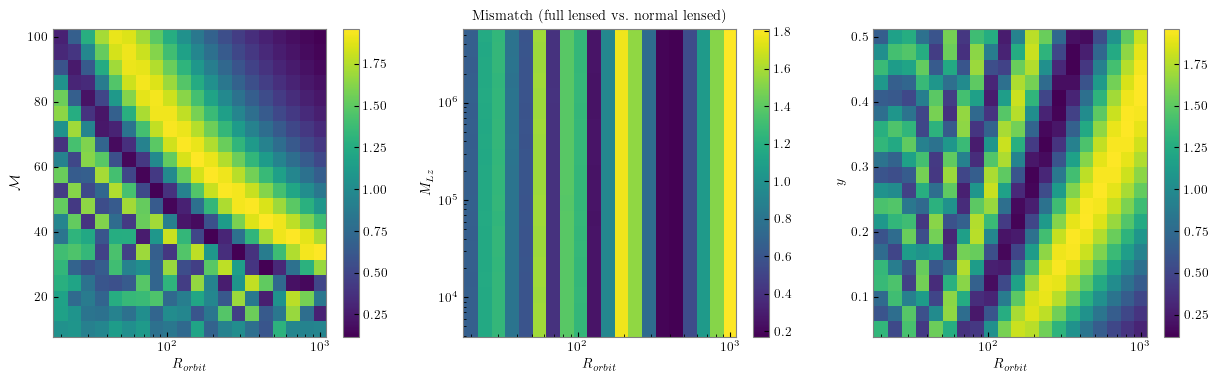

In [7]:
# Define a benchmark event
n = 20
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5)
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Waveform metadata
sampling_frequency = 1024.  # Hz
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2
N_freq_bins = 1000

# Make frequency grid
minimum_frequency_array = np.full(shape, minimum_frequency)
maximum_frequency_array = np.full(shape, maximum_frequency)
freq_grid = np.geomspace(minimum_frequency_array, maximum_frequency_array, N_freq_bins)

# Interpolate PSD
freq_array = np.geomspace(minimum_frequency, maximum_frequency, N_freq_bins)
psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = np.reshape(np.repeat(psd_interp, n**2), (-1, n, n))

# Sample parameter space
R_orbit_array = np.geomspace(20, 1000, n)
Mc_array = np.linspace(10, 100, n)
M_lz_array = np.geomspace(5e3, 5e6, n)
src_pos_array = np.linspace(0.05, 0.5, n)

# Prepare injections
R_orbit_mesh, Mc_mesh = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = R_orbit_mesh
events_copy_1['Mc'] = Mc_mesh

R_orbit_mesh, M_lz_mesh = np.meshgrid(R_orbit_array, M_lz_array, indexing='xy')
events_copy_2 = events.copy()
events_copy_2['R_orbit'] = R_orbit_mesh
events_copy_2['M_lz'] = M_lz_mesh

R_orbit_mesh, src_pos_mesh = np.meshgrid(R_orbit_array, src_pos_array, indexing='xy')
events_copy_3 = events.copy()
events_copy_3['R_orbit'] = R_orbit_mesh
events_copy_3['src_pos'] = src_pos_mesh

# Generate strains from L1
FD_strain_unlensed_1 = L1_BBH.GWstrain(freq_grid, events_copy_1)
FD_strain_lensed_1 = L1_AGN.GWstrain(freq_grid, events_copy_1)

FD_strain_unlensed_2 = L1_BBH.GWstrain(freq_grid, events_copy_2)
FD_strain_lensed_2 = L1_AGN.GWstrain(freq_grid, events_copy_2)

FD_strain_unlensed_3 = L1_BBH.GWstrain(freq_grid, events_copy_3)
FD_strain_lensed_3 = L1_AGN.GWstrain(freq_grid, events_copy_3)

# Combine unlensed waveforms to make normal lensed waveforms
FD_strain_normal_lensed_1 = normal_lens(FD_strain_unlensed_1, events_copy_1, freq_grid)
FD_strain_normal_lensed_2 = normal_lens(FD_strain_unlensed_2, events_copy_2, freq_grid)
FD_strain_normal_lensed_3 = normal_lens(FD_strain_unlensed_3, events_copy_3, freq_grid)

# Compute mismatch
mismatch_1 = mismatch(freq_grid, FD_strain_lensed_1, FD_strain_normal_lensed_1, psd_interp_grid)
mismatch_2 = mismatch(freq_grid, FD_strain_lensed_2, FD_strain_normal_lensed_2, psd_interp_grid)
mismatch_3 = mismatch(freq_grid, FD_strain_lensed_3, FD_strain_normal_lensed_3, psd_interp_grid)

# Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

ax = axs[0]
im = ax.pcolormesh(R_orbit_array, Mc_array, mismatch_1)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$\cal M$')

ax = axs[1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_2)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Mismatch (full lensed vs. normal lensed)')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$M_{Lz}$')

ax = axs[2]
im = ax.pcolormesh(R_orbit_array, src_pos_array, mismatch_3)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$y$')

These plots don't look qualitatively different from the ones done for mismatch between unlensed and second-order lensed waveforms.